In [ ]:
!unzip ClasLab.zip

In [ ]:
!mv  ./'Classification pytorch'/* ./*

# Обучение CNN классификатора

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.optim as optim

from tqdm import tqdm
import random
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from PIL import Image

%matplotlib inline

In [ ]:
# Установка стилистики графиков
plt.style.use('ggplot')
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [ ]:
# Установка Seed для воспроизводимости
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
# Загрузим предварительно обученную модель ResNet50
model = models.resnet50(pretrained=True)

# Заменим последний слой (fully connected) так, чтобы количество выходных каналов соответствовало 3 классам
num_classes = 3
model.fc = nn.Linear(model.fc.in_features, num_classes)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 126MB/s]


# Без особых аугментаций

In [ ]:
# Определим пути к данным
train_data_dir = '/content/sample_data/dataset/train'
val_data_dir = '/content/sample_data/dataset/validation'

# Определим трансформации
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# Создадим датасеты
train_dataset = ImageFolder(train_data_dir, transform=train_transforms)
val_dataset = ImageFolder(val_data_dir, transform=val_transforms)

# Создадим датагенераторы
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Список классов:

In [ ]:
classes_list = train_dataset.classes
print(classes_list)

['adidas', 'converse', 'nike']


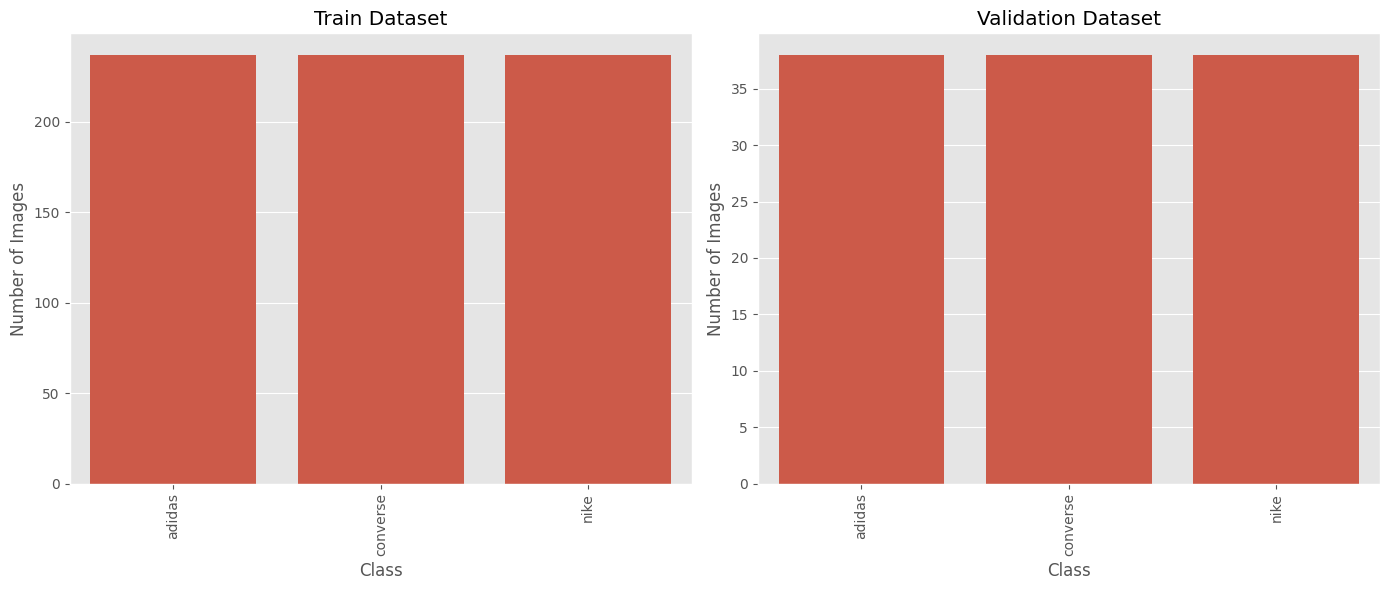

In [ ]:
# Подсчитать количество изображений в каждом классе для обучающего набора данных
train_class_counts = np.zeros(len(train_dataset.classes))
for _, label in train_dataset:
    train_class_counts[label] += 1

# Подсчитать количество изображений в каждом классе для валидационного набора данных
val_class_counts = np.zeros(len(val_dataset.classes))
for _, label in val_dataset:
    val_class_counts[label] += 1

# Создать barplot
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Barplot для обучающего набора данных
sns.barplot(x=train_dataset.classes, y=train_class_counts, ax=ax[0])
ax[0].set_title('Train Dataset')
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Number of Images')
ax[0].tick_params(axis='x', rotation=90)

# Barplot для валидационного набора данных
sns.barplot(x=val_dataset.classes, y=val_class_counts, ax=ax[1])
ax[1].set_title('Validation Dataset')
ax[1].set_xlabel('Class')
ax[1].set_ylabel('Number of Images')
ax[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Пример фоток после нормализации:

Images without normalization:


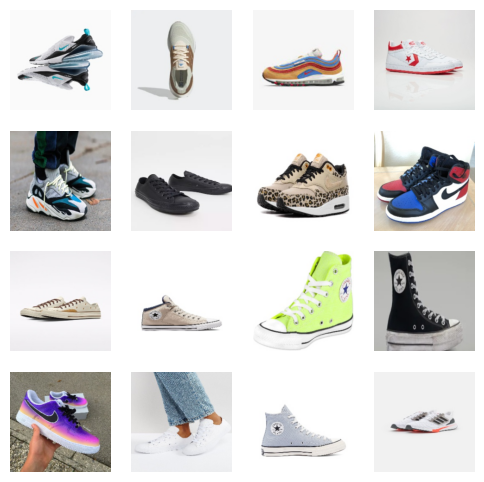

In [ ]:
# Функция для отображения изображений из батча
def show_images(images, denormalize=False):
    if denormalize:
        # Обратное преобразование для нормализации
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        images = images.numpy().transpose((0, 2, 3, 1))
        images = std * images + mean
        images = np.clip(images, 0, 1)
    else:
        images = images.numpy().transpose((0, 2, 3, 1))
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        ax.axis('off')
    plt.show()

# Получение первого батча из тренировочного загрузчика данных
images, _ = next(iter(train_loader))

# Отображение изображений с восстановлением цветов
print("Images without normalization:")
show_images(images, denormalize=False)

Сколько в одной эпохе проходов по батчам:

In [ ]:
len(train_loader), len(val_loader)

(12, 2)

Пример данных в датасете и даталоадере:

In [ ]:
train_dataset[0]

(tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]),
 0)

In [ ]:
next(iter(train_loader))

[tensor([[[[0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.9922],
           [0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.9922],
           [0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.9922],
           ...,
           [0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.9922],
           [0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.9922],
           [0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.9922]],
 
          [[0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
           [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
           [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
           ...,
           [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
           [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
           [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961]],
 
          [[0.9725, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 0.9725],
           [0.9725, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 0.9725],
           [0.9725, 0.97

In [ ]:
# Валидация модели до обучения:
model.eval()
model.to(device)
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(val_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
val_accuracy = correct / total
print(val_accuracy)

100%|██████████| 2/2 [00:01<00:00,  1.43it/s]

0.3333333333333333


# Обучение сети:

In [ ]:
# Определим функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# число эпох
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_accuracy = 0
model.to(device)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Валидация модели
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, '
          f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

    # Сохранение лучшей модели на основе валидационной точности
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print('Saved best model!')

    # Сохранение последней актуальной модели
    torch.save(model.state_dict(), 'last_model.pth')
    print()

print('Training and validation complete!')

100%|██████████| 2/2 [00:00<00:00,  3.55it/s]


Epoch [1/10], Train Loss: 0.6147, Train Accuracy: 0.7117, Val Loss: 3.6522, Val Accuracy: 0.6316
Saved best model!



100%|██████████| 2/2 [00:00<00:00,  3.65it/s]


Epoch [2/10], Train Loss: 0.3400, Train Accuracy: 0.8833, Val Loss: 2.6416, Val Accuracy: 0.6667
Saved best model!



100%|██████████| 2/2 [00:00<00:00,  3.45it/s]


...

Epoch [8/10], Train Loss: 0.0359, Train Accuracy: 0.9859, Val Loss: 0.4119, Val Accuracy: 0.9035
Saved best model!



100%|██████████| 2/2 [00:00<00:00,  3.58it/s]


Epoch [9/10], Train Loss: 0.0414, Train Accuracy: 0.9859, Val Loss: 0.3808, Val Accuracy: 0.8684



100%|██████████| 2/2 [00:00<00:00,  3.58it/s]


Epoch [10/10], Train Loss: 0.0688, Train Accuracy: 0.9859, Val Loss: 0.8773, Val Accuracy: 0.8421

Training and validation complete!


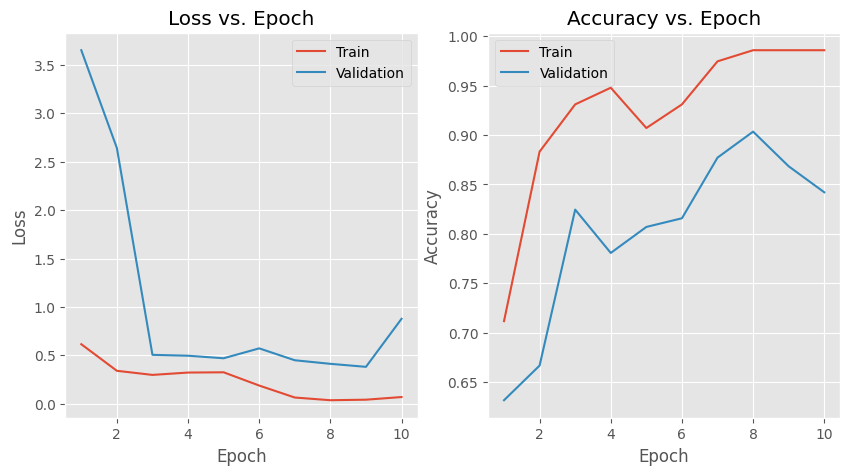

In [ ]:
# Построим графики
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label='Train')
plt.plot(range(1, num_epochs+1), val_accuracies, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()


Оценка качества:

In [ ]:
# Получение метрик качества для текущих весов модели
def evaluate_model(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    accuracy = np.sum(np.diag(cm)) / np.sum(cm)
    # Вычисление взвешенной F1-меры для текущей модели
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, report, accuracy, weighted_f1

# Функция для построения графика матрицы ошибок
def plot_confusion_matrix(cm, classes):
    with plt.style.context('default'):
        plt.figure(figsize=(5, 4))
        sns.set(font_scale=1.0)
        sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
                    xticklabels=classes, yticklabels=classes)
        plt.xlabel('Predicted labels')
        plt.ylabel('True labels')
        plt.title('Confusion Matrix')
        plt.show()

Metrics for current model:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        38
           1       0.92      0.89      0.91        38
           2       0.89      0.87      0.88        38

    accuracy                           0.90       114
   macro avg       0.90      0.90      0.90       114
weighted avg       0.90      0.90      0.90       114

Test Accuracy: 0.9035


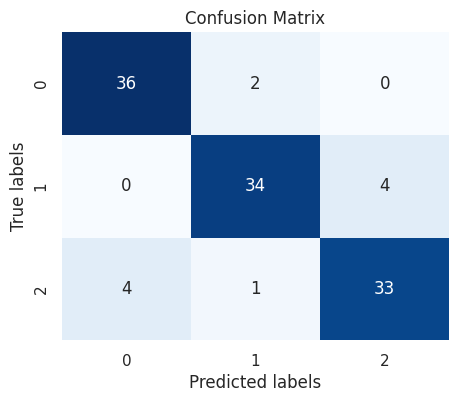

In [ ]:
# Загрузка весов модели
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)

# Оценка модели и построение матрицы ошибок
cm, report, accuracy_1, weighted_f1_1 = evaluate_model(model, val_loader)
print("Metrics for current model:")
print(report)
print(f'Test Accuracy: {accuracy_1:.4f}')
plot_confusion_matrix(cm, classes=list(range(3)))

# Добавим аугментаций

In [ ]:
# Загрузим предварительно обученную модель ResNet50
model = models.resnet50(pretrained=True)

# Заменим последний слой (fully connected) так, чтобы количество выходных каналов соответствовало 3 классам
num_classes = 3
model.fc = nn.Linear(model.fc.in_features, num_classes)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Определим пути к данным
train_data_dir = '/content/sample_data/dataset/train'
val_data_dir = '/content/sample_data/dataset/validation'

# Определим трансформации
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomRotation(10),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(0.5),  # Добавим вертикальное отражение
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Создадим датасеты
train_dataset = ImageFolder(train_data_dir, transform=train_transforms)
val_dataset = ImageFolder(val_data_dir, transform=val_transforms)

# Создадим датагенераторы
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Пример фоток после аугментации:

Images without normalization:


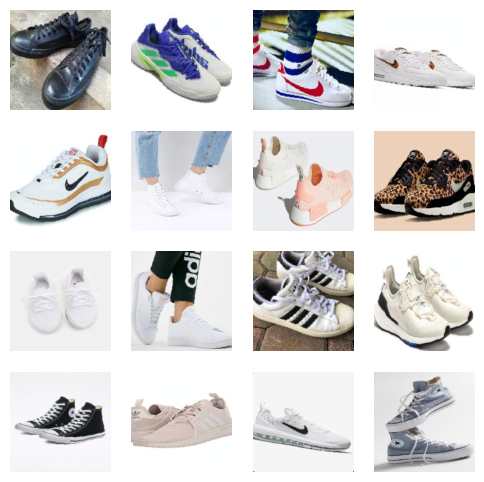

In [ ]:
# Получение первого батча из тренировочного загрузчика данных
images, _ = next(iter(train_loader))

# Отображение изображений с восстановлением цветов
print("Images without normalization:")
show_images(images, denormalize=True)

### код обучения:

In [ ]:
# Определим функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# число эпох
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_accuracy = 0
model.to(device)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Валидация модели
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, '
          f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

    # Сохранение лучшей модели на основе валидационной точности
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print('Saved best model!')

    # Сохранение последней актуальной модели
    torch.save(model.state_dict(), 'last_model.pth')
    print()

print('Training and validation complete!')

100%|██████████| 4/4 [00:00<00:00,  5.37it/s]


Epoch [1/10], Train Loss: 0.6635, Train Accuracy: 0.7075, Val Loss: 2.5474, Val Accuracy: 0.6930
Saved best model!



100%|██████████| 4/4 [00:00<00:00,  5.41it/s]


Epoch [2/10], Train Loss: 0.5512, Train Accuracy: 0.7904, Val Loss: 0.6092, Val Accuracy: 0.7982
Saved best model!



100%|██████████| 4/4 [00:00<00:00,  6.45it/s]


...

Epoch [8/10], Train Loss: 0.1656, Train Accuracy: 0.9437, Val Loss: 0.4154, Val Accuracy: 0.8684



100%|██████████| 4/4 [00:00<00:00,  6.67it/s]


Epoch [9/10], Train Loss: 0.2156, Train Accuracy: 0.9212, Val Loss: 1.1312, Val Accuracy: 0.7368



100%|██████████| 4/4 [00:00<00:00,  6.65it/s]


Epoch [10/10], Train Loss: 0.1626, Train Accuracy: 0.9522, Val Loss: 0.5624, Val Accuracy: 0.8684

Training and validation complete!


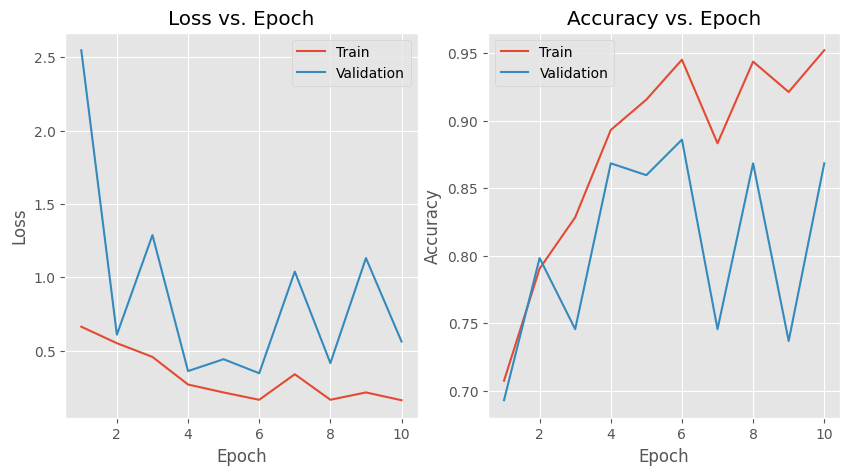

In [ ]:
# Построим графики
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label='Train')
plt.plot(range(1, num_epochs+1), val_accuracies, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()

Оценка качества:

Metrics for current model:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85        38
           1       0.93      0.97      0.95        38
           2       0.85      0.87      0.86        38

    accuracy                           0.89       114
   macro avg       0.89      0.89      0.89       114
weighted avg       0.89      0.89      0.89       114

Test Accuracy: 0.8860


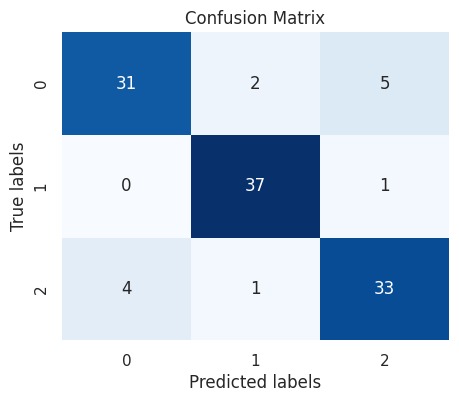

In [ ]:
# Загрузка весов модели
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)

# Оценка модели и построение матрицы ошибок
cm, report, accuracy_2, weighted_f1_2 = evaluate_model(model, val_loader)
print("Metrics for current model:")
print(report)
print(f'Test Accuracy: {accuracy_2:.4f}')
plot_confusion_matrix(cm, classes=list(range(3)))

---

# Инференс готовой модели

In [ ]:
# Загрузим предварительно обученную модель ResNet50
model = models.resnet50()
# Заменим последний слой (fully connected) так, чтобы количество выходных каналов соответствовало 3 классам
num_classes = 3
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Загрузка весов модели
model.load_state_dict(torch.load('best_model.pth'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# Предобработка изображения
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

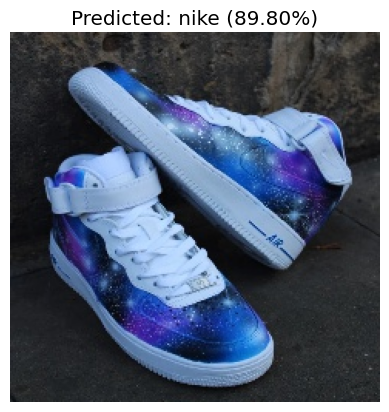

In [ ]:
# Загрузим изображение для инференса
image_path = '/content/sample_data/dataset/validation/nike/4.jpg'
image = Image.open(image_path)
image_tensor = preprocess(image)
image_tensor = image_tensor.unsqueeze(0).to(device)  # Добавляем размер батча

# Прогоняем изображение через модель
with torch.no_grad():
    output = model(image_tensor)

# Применяем softmax для получения вероятностей классов
probabilities = torch.nn.functional.softmax(output[0], dim=0).cpu()

# Отображение результатов
top_prob, top_class = torch.topk(probabilities, 1)
top_prob = top_prob.item()
top_class = top_class.item()

# Получаем имя класса
class_names = ['adidas', 'converse', 'nike']
class_name = class_names[top_class]

# Отображаем изображение
plt.imshow(image)
plt.axis('off')
plt.title(f'Predicted: {class_name} ({top_prob*100:.2f}%)')
plt.show()

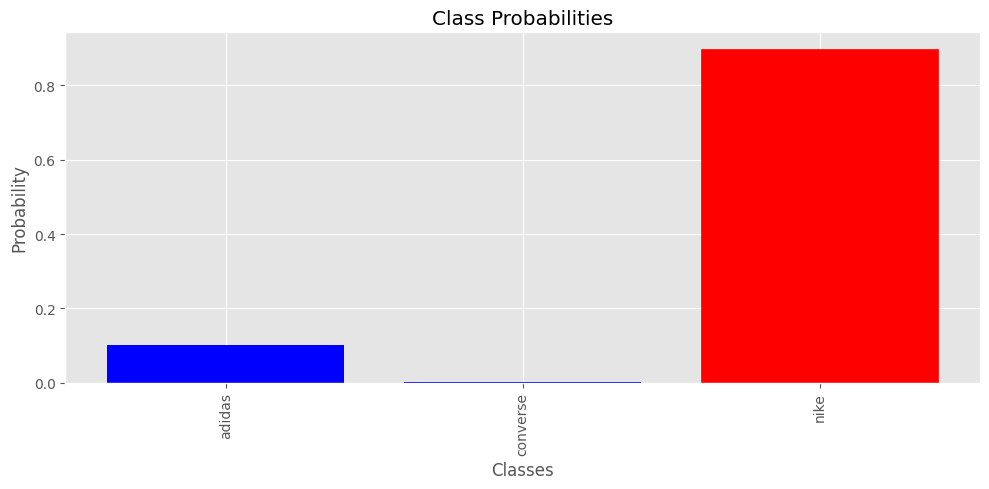

In [ ]:
# Построим барплот
plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(probabilities)), probabilities, color='blue')
plt.xlabel('Classes')
plt.ylabel('Probability')
plt.title('Class Probabilities')
plt.xticks(range(len(probabilities)), class_names, rotation='vertical')

# Подсвечиваем класс с наибольшей уверенностью
bars[top_class].set_color('red')

plt.tight_layout()
plt.show()